In [ ]:
import zipfile
import datetime
import string
import math
import os

import tqdm
import matplotlib.pyplot as plt
import tensorflow as tf
import sklearn.model_selection

import keras_ocr

from PIL import Image


In [ ]:
data_dir = '../data'


In [ ]:
alphabet = string.digits + string.ascii_letters + '!?. '
recognizer_alphabet = ''.join(sorted(set(alphabet.lower())))
fonts = keras_ocr.data_generation.get_fonts(
    alphabet=alphabet,
    cache_dir=data_dir
)


In [ ]:
backgrounds = keras_ocr.data_generation.get_backgrounds(cache_dir=data_dir)

In [ ]:
def list_ttf_files(directory):
    """
    Returns a list of paths to all .ttf files in the given directory.
    
    Parameters:
    directory (str): The path to the directory to search.
    
    Returns:
    list: A list of file paths to all .ttf files in the directory.
    """
    ttf_files = []
    for root, dirs, files in os.walk(directory):
        for file in files:
            if file.endswith('.ttf'):
                ttf_files.append(os.path.join(root, file))
    return ttf_files

In [ ]:
fonts = list_ttf_files("../data/fonts")

In [ ]:
len(backgrounds)

In [ ]:
len(fonts)

In [ ]:
text_generator = keras_ocr.data_generation.get_text_generator(alphabet=alphabet)
print('The first generated text is:', next(text_generator))

def get_train_val_test_split(arr):
    train, valtest = sklearn.model_selection.train_test_split(arr, train_size=0.8, random_state=42)
    val, test = sklearn.model_selection.train_test_split(valtest, train_size=0.5, random_state=42)
    return train, val, test

background_splits = get_train_val_test_split(backgrounds)
font_splits = get_train_val_test_split(fonts)



The first generated validation image (below) contains: Is le
d theories
beca
me


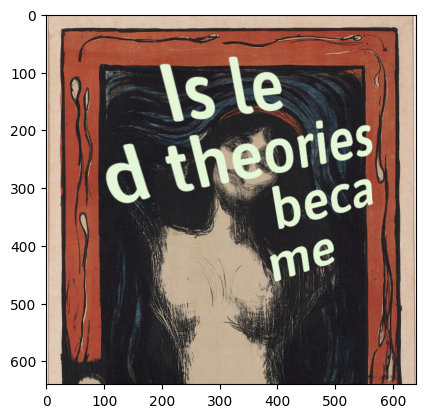

In [34]:
image_generators = [
    keras_ocr.data_generation.get_image_generator(
        height=640,
        width=640,
        text_generator=text_generator,
        font_groups={
            alphabet: current_fonts
        },
        backgrounds=current_backgrounds,
        font_size=(60, 120),
        margin=50,
        rotationX=(-0.05, 0.05),
        rotationY=(-0.05, 0.05),
        rotationZ=(-15, 15)
    )  for current_fonts, current_backgrounds in zip(
        font_splits,
        background_splits
    )
]

# See what the first validation image looks like.
image, lines = next(image_generators[1])
text = keras_ocr.data_generation.convert_lines_to_paragraph(lines)
print('The first generated validation image (below) contains:', text)
plt.imshow(image)

In [20]:
backgrounds[0]

'../data/backgrounds/1024px-dome_of_church_in_palazzo_farnese_%28caprarola%29.jpg'

In [ ]:
import itertools
import pandas as pd
from PIL import Image

In [ ]:
columns = ['c', 'x1', 'y1', 'x2', 'y2', 'x3', 'y3', 'x4', 'y4']

In [35]:
target = 'val'

j = 103

for i in range(len(background_splits[1])):
    try:
        # Generate image and lines
        image, lines = next(image_generators[0])
        lines = list(itertools.chain(*lines))
        rows = []
        
        # Process lines
        for coord_array, c in lines:
            coordinates = coord_array.flatten().tolist()
            rows.append([c] + coordinates)
        
        # Save the generated image
        image_path = f"/home/jcibeira/character_clasification_and_detection/data/generated_images/{target}/images/image_{j}.jpg"
        try:
            Image.fromarray(image).save(image_path)
        except Exception as e:
            print(f"Error saving image at {image_path}: {e}")
            continue

        # Save the coordinates in a CSV file
        csv_path = f"/home/jcibeira/character_clasification_and_detection/data/generated_images/{target}/boxes/boxes_{j}.csv"
        try:
            df = pd.DataFrame(rows, columns=columns)
            df.to_csv(csv_path, index=False)
        except Exception as e:
            print(f"Error saving CSV at {csv_path}: {e}")
            continue
        j += 1

    except Exception as e:
        print(f"Error processing image {i}: {e}")



In [38]:
target = 'test'

images_dir = f"/home/jcibeira/character_clasification_and_detection/data/generated_images/{target}/images"
boxes_dir = f"/home/jcibeira/character_clasification_and_detection/data/generated_images/{target}/boxes"
output_dir = f"/home/jcibeira/character_clasification_and_detection/data/clasiffier/{target}"

for i in range(len(os.listdir(images_dir))):
    # Define image and csv file paths
    image_path = os.path.join(images_dir, f"image_{i}.jpg")
    csv_path = os.path.join(boxes_dir, f"boxes_{i}.csv")
    
    # Open the image
    image = Image.open(image_path)
    
    # Load the CSV file with bounding box coordinates
    df = pd.read_csv(csv_path)

    # Loop through each row in the CSV
    for idx, row in df.iterrows():
        character = row['c']
        if character == '.':
            character = 'dot'
        coordinates = row[['x1', 'y1', 'x2', 'y2', 'x3', 'y3', 'x4', 'y4']].values.reshape((4, 2))
        
        # Calculate bounding box to crop
        x_min = min(coordinates[:, 0])
        x_max = max(coordinates[:, 0])
        y_min = min(coordinates[:, 1])
        y_max = max(coordinates[:, 1])
        
        # Crop the character from the image
        character_crop = image.crop((x_min, y_min, x_max, y_max))

        # Define character directory and save path
        char_dir = os.path.join(output_dir, character)
        os.makedirs(char_dir, exist_ok=True)
        
        # Try saving the cropped character, skip if it's empty
        try:
            if character_crop.size[0] > 0 and character_crop.size[1] > 0:
                character_crop.save(os.path.join(char_dir, f"{character}_{i}_{idx}.jpg"))
            else:
                print(f"Skipped empty crop for character '{character}' in image_{i}.jpg")
        except ValueError as e:
            print(f"Error saving character '{character}' in image_{i}.jpg: {e}")
            continue  # Skip this crop if there's an error



Skipped empty crop for character ' ' in image_0.jpg
Skipped empty crop for character ' ' in image_5.jpg
Skipped empty crop for character ' ' in image_6.jpg
Skipped empty crop for character ' ' in image_6.jpg
Skipped empty crop for character ' ' in image_6.jpg
Skipped empty crop for character ' ' in image_7.jpg
Skipped empty crop for character ' ' in image_7.jpg
Skipped empty crop for character ' ' in image_7.jpg
Skipped empty crop for character ' ' in image_8.jpg
Skipped empty crop for character ' ' in image_8.jpg
Skipped empty crop for character ' ' in image_11.jpg
Skipped empty crop for character ' ' in image_11.jpg
Skipped empty crop for character ' ' in image_12.jpg
Skipped empty crop for character ' ' in image_12.jpg
Skipped empty crop for character ' ' in image_12.jpg
Skipped empty crop for character ' ' in image_16.jpg
Skipped empty crop for character ' ' in image_16.jpg
Skipped empty crop for character ' ' in image_17.jpg
Skipped empty crop for character ' ' in image_17.jpg
Ski

In [ ]:

def list_directories(path):
    """Return a list of directory names inside the specified directory path."""
    try:
        return [name for name in os.listdir(path) if os.path.isdir(os.path.join(path, name))]
    except FileNotFoundError:
        print(f"The directory '{path}' does not exist.")
        return []

In [ ]:
directory_path_train = "/home/jcibeira/character_clasification_and_detection/data/clasiffier/train"
directories_train = list_directories(directory_path_train)

directory_path_val = "/home/jcibeira/character_clasification_and_detection/data/clasiffier/val"
directories_val = list_directories(directory_path_val)

directory_path_test = "/home/jcibeira/character_clasification_and_detection/data/clasiffier/test"
directories_test = list_directories(directory_path_test)

In [ ]:
set(directories_train) - set(directories_val)

In [ ]:
set(directories_train) - set(directories_test)